# 04 – KMeans Exploration (non supervisé)

**Entrée** : data/processed/attrition_with_avg_hours.csv

**Méthode** : KMeans (k = 2 à 6), sélection interprétée du k

**Objectif** : Segmentation exploratoire des employés — outil indicatif, non prédictif

## 1. Imports

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

PROCESSED_DIR = os.path.join('..', 'data', 'processed')
FIG_DIR = Path('..', 'reports', 'figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Chargement des données

In [50]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'attrition_with_avg_hours.csv'))
print(f'Shape : {df.shape}')
print(f'NaN   : {df.isna().sum().sum()}')
print(f'\nDistribution Attrition :')
print(df['Attrition'].value_counts())

Shape : (4410, 27)
NaN   : 0

Distribution Attrition :
Attrition
0    3699
1     711
Name: count, dtype: int64


## 3. Sélection des features

On retient **9 variables numériques** pertinentes pour le clustering :
- Démographiques : Age, DistanceFromHome
- Carrière : MonthlyIncome, TotalWorkingYears, YearsAtCompany
- Satisfaction : EnvironmentSatisfaction, JobSatisfaction, WorkLifeBalance
- Badgeuse : avg_work_hours

In [51]:
feature_cols = [
    'Age',
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany',
    'DistanceFromHome',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'WorkLifeBalance',
    'avg_work_hours'
]

X = df[feature_cols].copy()
print(f'Features retenues : {len(feature_cols)}')
print(f'NaN dans X : {X.isnull().sum().sum()}')
print(f'Colonnes : {feature_cols}')

Features retenues : 9
NaN dans X : 0
Colonnes : ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'avg_work_hours']


## 3.1. Analyse des corrélations

Visualization des relations entre les features via un pairplot.

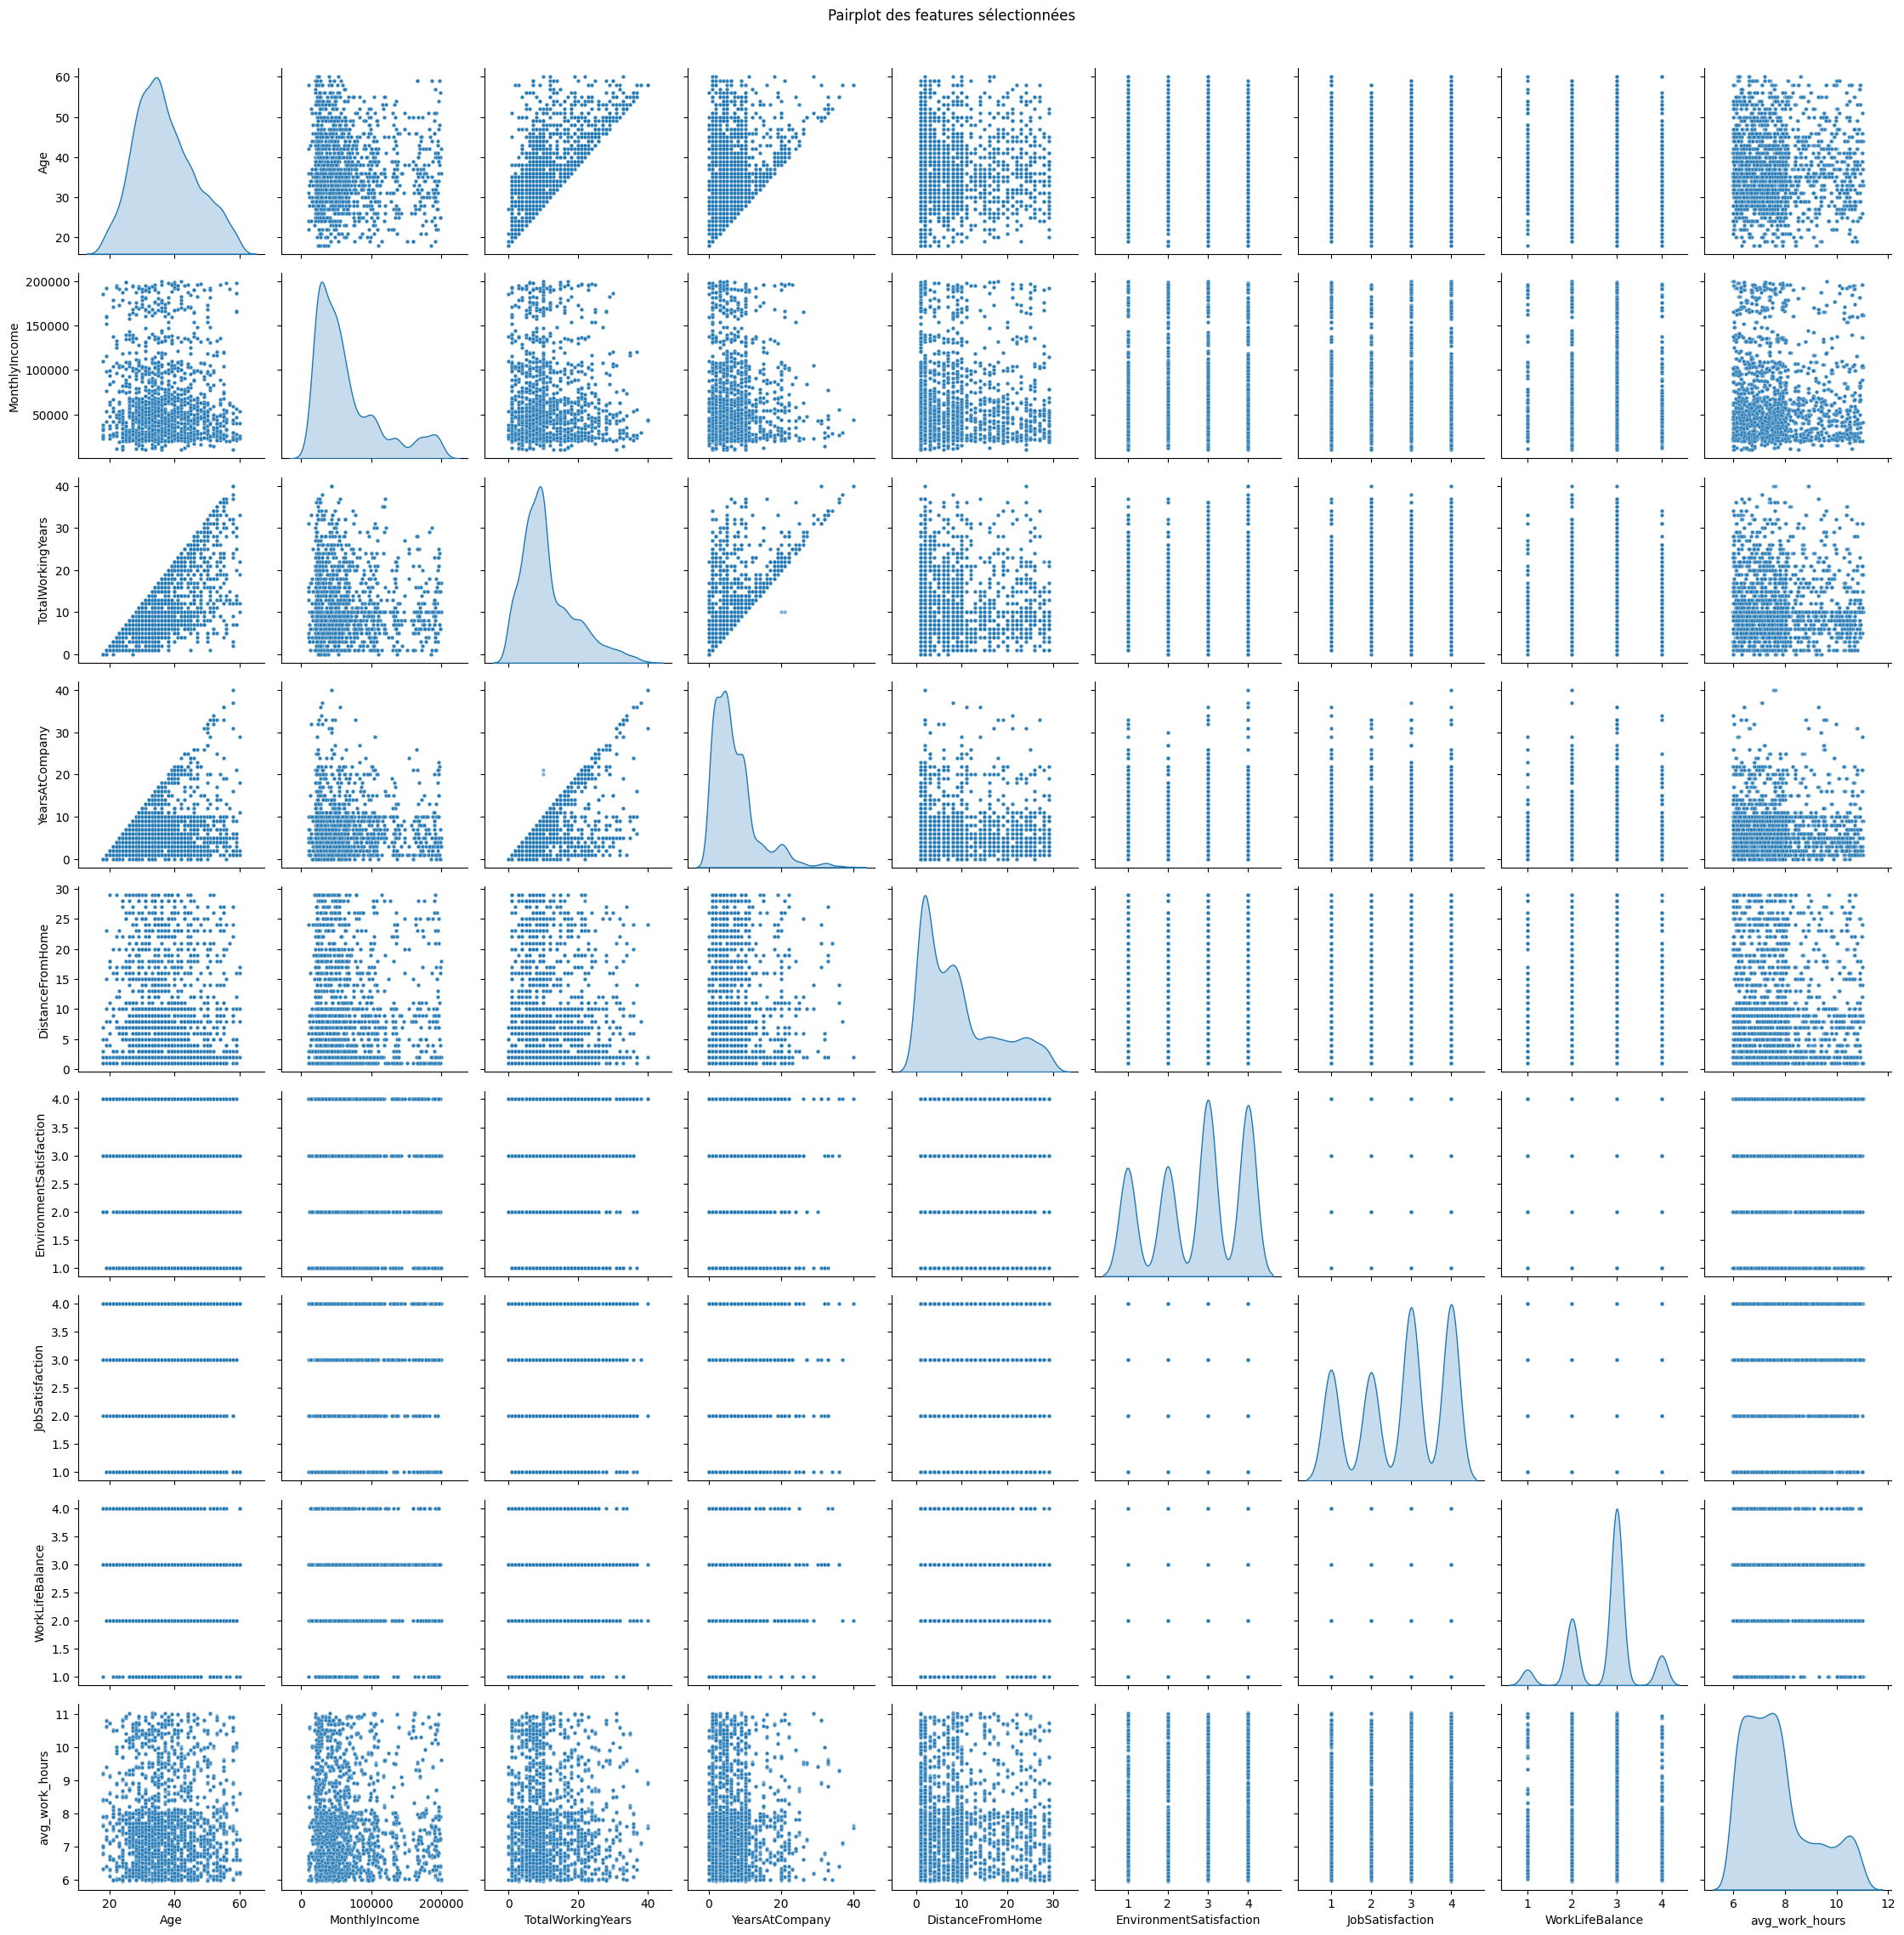

Figure sauvegardée : ..\reports\figures\kmeans_pairplot.png


In [52]:
# Pairplot pour visualiser les corrélations entre features
sns.pairplot(X, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 10}, corner=False)
plt.suptitle('Pairplot des features sélectionnées', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {FIG_DIR / "kmeans_pairplot.png"}')

## 4. Standardisation

In [53]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'X_scaled shape : {X_scaled.shape}')

X_scaled shape : (4410, 9)


## 5. Test de k = 2 à 6

On calcule le score silhouette et l'inertie pour chaque valeur de k.

In [54]:
K_RANGE = range(2, 10)
results = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    results.append({'k': k, 'inertia': km.inertia_, 'silhouette': round(sil, 4)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 k      inertia  silhouette
 2 33740.780236      0.1887
 3 30949.904989      0.1313
 4 28637.559516      0.1313
 5 26727.369630      0.1226
 6 25156.784006      0.1280
 7 23733.973105      0.1275
 8 22725.591254      0.1210
 9 21962.518974      0.1123


## 6. Courbe Silhouette

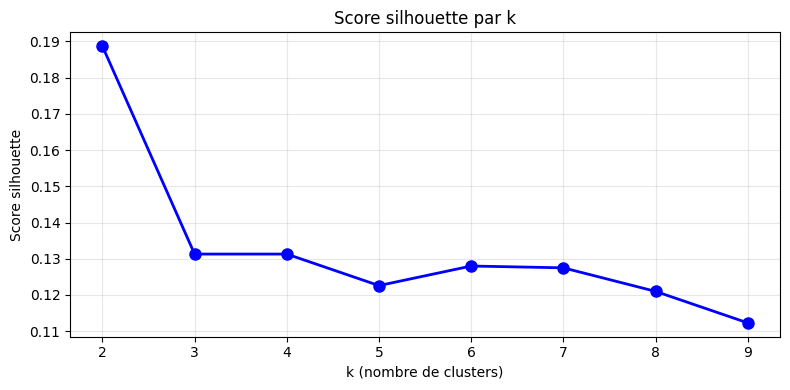

Figure sauvegardée : ..\reports\figures\kmeans_silhouette.png


In [55]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['k'], results_df['silhouette'], 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('k (nombre de clusters)')
ax.set_ylabel('Score silhouette')
ax.set_title('Score silhouette par k')
ax.set_xticks(list(K_RANGE))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_silhouette.png', dpi=300, bbox_inches='tight')

plt.show()
print(f'Figure sauvegardée : {FIG_DIR / "kmeans_silhouette.png"}')

## 7. Courbe Elbow (inertie)

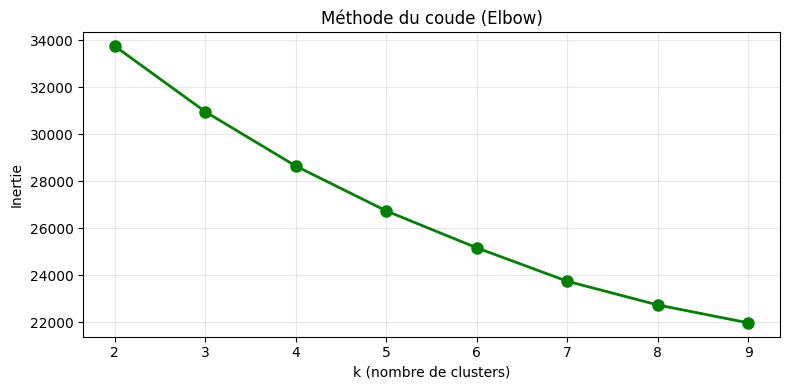

Figure sauvegardée : ..\reports\figures\kmeans_elbow.png


In [56]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['k'], results_df['inertia'], 'go-', linewidth=2, markersize=8)
ax.set_xlabel('k (nombre de clusters)')
ax.set_ylabel('Inertie')
ax.set_title('Méthode du coude (Elbow)')
ax.set_xticks(list(K_RANGE))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_elbow.png', dpi=300, bbox_inches='tight')

plt.show()
print(f'Figure sauvegardée : {FIG_DIR / "kmeans_elbow.png"}')

## 8. Choix de k et clustering final

**Interprétation** : les scores silhouette sont faibles (< 0.20), ce qui est courant sur des données RH hétérogènes.
k = 2 obtient le meilleur score silhouette (≈ 0.19), mais k = 3 offre une segmentation plus fine et interprétable.
Le coude de l'inertie montre une décélération nette entre k = 2 et k = 3.

On retient **k = 3** comme compromis entre séparabilité et granularité.

In [57]:
CHOSEN_K = 3

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster'])
print(f'k choisi       : {CHOSEN_K}')
print(f'Silhouette     : {sil_final:.4f}')
print(f'Inertie        : {kmeans.inertia_:.2f}')
print(f'Tailles        : {df["cluster"].value_counts().sort_index().tolist()}')

k choisi       : 3
Silhouette     : 0.1313
Inertie        : 30949.90
Tailles        : [2475, 949, 986]


## 9. Projection PCA 2D

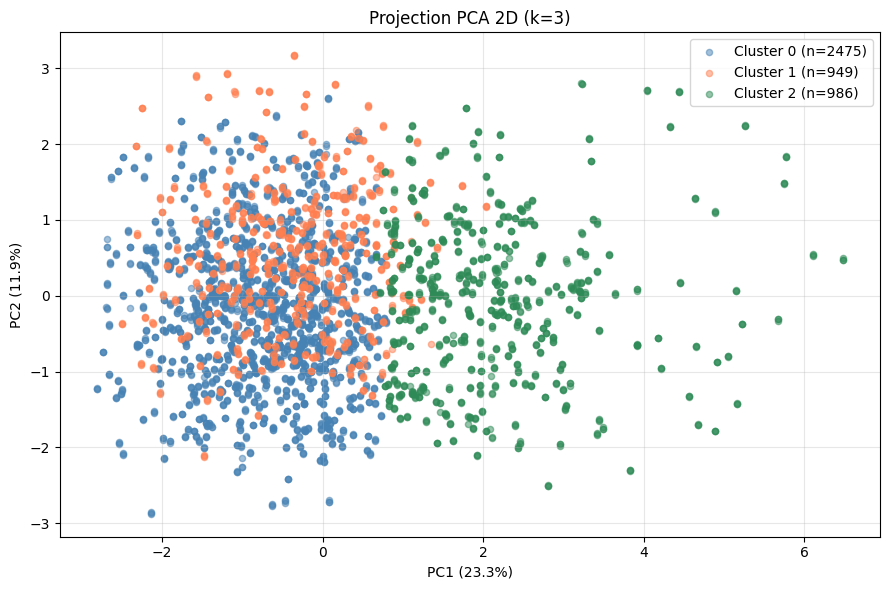

Figure sauvegardée : ..\reports\figures\kmeans_pca.png


In [58]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue', 'coral', 'seagreen', 'goldenrod']

for c in range(CHOSEN_K):
    mask = df['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               alpha=0.5, s=20, color=colors[c],
               label=f'Cluster {c} (n={mask.sum()})')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'Projection PCA 2D (k={CHOSEN_K})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_pca.png', dpi=300, bbox_inches='tight')

plt.show()
print(f'Figure sauvegardée : {FIG_DIR / "kmeans_pca.png"}')

## 10. Taux d'attrition par cluster

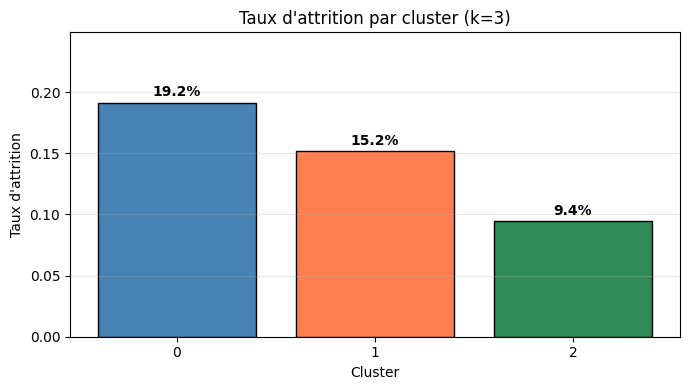

Figure sauvegardée : ..\reports\figures\kmeans_attrition.png


In [59]:
attrition_by_cluster = df.groupby('cluster')['Attrition'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(range(CHOSEN_K), attrition_by_cluster.values,
              color=colors[:CHOSEN_K], edgecolor='black')

for bar, val in zip(bars, attrition_by_cluster.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', fontweight='bold')

ax.set_xlabel('Cluster')
ax.set_ylabel("Taux d'attrition")
ax.set_title(f"Taux d'attrition par cluster (k={CHOSEN_K})")
ax.set_xticks(range(CHOSEN_K))
ax.set_ylim(0, max(attrition_by_cluster.values) * 1.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_attrition.png', dpi=300, bbox_inches='tight')

plt.show()
print(f'Figure sauvegardée : {FIG_DIR / "kmeans_attrition.png"}')

## 11. Export

In [60]:
output_path = os.path.join(PROCESSED_DIR, 'kmeans_clusters.csv')
df.to_csv(output_path, index=False)

print(f'Export : {output_path}')
print(f'Shape  : {df.shape}')

Export : ..\data\processed\kmeans_clusters.csv
Shape  : (4410, 28)


## 12. Validation finale

In [61]:
print(f'df.shape          : {df.shape}')
print(f'NaN total         : {df.isna().sum().sum()}')
print(f'Nb features       : {len(feature_cols)}')
print(f'Nb clusters       : {CHOSEN_K}')
print(f'Silhouette        : {sil_final:.4f}')

assert df.isna().sum().sum() == 0, 'Il reste des NaN'
assert len(feature_cols) <= 10, f'Trop de features : {len(feature_cols)}'
assert CHOSEN_K <= 4, f'Trop de clusters : {CHOSEN_K}'
print('\nToutes les validations passent.')

df.shape          : (4410, 28)
NaN total         : 0
Nb features       : 9
Nb clusters       : 3
Silhouette        : 0.1313

Toutes les validations passent.
